In [1]:
import torch
import  torch.nn as nn
from torchvision.transforms import ToTensor
from torchvision.datasets import FashionMNIST

In [2]:
mnist_train_raw = FashionMNIST('.',download=True,train=True,transform=ToTensor())
mnist_test_raw = FashionMNIST('.',download=True,train=False,transform=ToTensor())

In [4]:
data_loader = torch.utils.data.DataLoader(mnist_train_raw, batch_size=64)    

In [5]:
data_loader_test = torch.utils.data.DataLoader(mnist_test_raw, batch_size=64)    

In [3]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # Avoid OpenMP crash



In [6]:
images, labels = next(iter(data_loader)) 

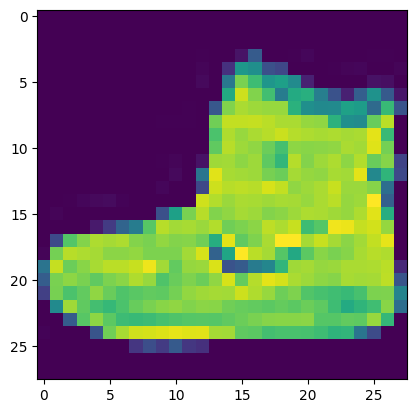

In [7]:
import matplotlib.pyplot as plt
plt.imshow(images[0,0])

In [10]:
class NNIC(nn.Module):
    def __init__(self,*args,**kwargs):
        super().__init__(*args,**kwargs)
        self.model = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
    def forward(self,x):
        x = x.view(x.size(0), -1)
        pred = self.model(x)
        return pred



In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [11]:
model = NNIC()
model.to(device=device)
criternion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [ ]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(log_dir="runs/experiment1")

In [15]:
# from tqdm.notebook import tqdm
global_step = 0
model.train()
for epoch in range(10):# tqdm(range(10)):
    for img, lbl in data_loader:# tqdm(data_loader):
        img, lbl = img.to(device), lbl.to(device)
        pred = model(img)

        loss = criternion(pred,lbl)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # writer.add_scalar("Loss/train", loss.item(), global_step)
        global_step+=1
    print(loss.item())
# writer.close()



0.4453951120376587
0.2683948278427124
0.30214357376098633
0.5819454193115234
0.33826491236686707
0.3540058135986328
0.3051414489746094
0.263888418674469
0.3104504346847534
0.27276158332824707


In [16]:
model.eval()
with torch.no_grad():
    for x,y in data_loader_test:
        x,y = x.to(device), y.to(device)
        pred = model(x)

        loss = criternion(pred,y)
        print(loss.item())

0.3403884172439575
0.2685636281967163
0.42522066831588745
0.4738842844963074
0.271312952041626
0.6113380789756775
0.3781113028526306
0.48496150970458984
0.4910719692707062
0.39293035864830017
0.5471878051757812
0.5401718616485596
0.3663167953491211
0.2472096085548401
0.4223010241985321
0.6177516579627991
0.19286952912807465
0.574638307094574
0.4854138493537903
0.42705535888671875
0.5669241547584534
0.40726256370544434
0.3889850974082947
0.4560108184814453
0.2949342131614685
0.4086710512638092
0.2419690489768982
0.4271122217178345
0.46902498602867126
0.34939873218536377
0.5431888699531555
0.7364125847816467
0.42597898840904236
0.28801965713500977
0.15135397017002106
0.3449416160583496
0.5754001140594482
0.3086145520210266
0.5562704205513
0.5877943634986877
0.6063463091850281
0.462256520986557
0.54013592004776
0.2770322561264038
0.6261842846870422
0.8494181632995605
0.40899142622947693
0.5251815915107727
0.4809841811656952
0.2987920343875885
0.7999078035354614
0.645072340965271
0.4488918

In [30]:
checkpoint = {
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': loss
}
torch.save(checkpoint, "checkpoint.pth")

In [32]:
optimizer.state_dict()

{'state': {0: {'step': tensor(11984.),
   'exp_avg': tensor([[-5.6052e-45,  5.6052e-45,  5.6052e-45,  ..., -5.6052e-45,
            -5.6052e-45, -5.6052e-45],
           [-5.6052e-45, -5.6052e-45, -4.6483e-22,  ..., -1.0286e-21,
             5.6052e-45, -5.6052e-45],
           [-5.6052e-45,  5.6052e-45,  5.6052e-45,  ...,  5.6052e-45,
             5.6052e-45,  5.6052e-45],
           ...,
           [ 0.0000e+00,  0.0000e+00,  5.6052e-45,  ...,  5.6052e-45,
             0.0000e+00,  0.0000e+00],
           [ 5.6052e-45,  5.6052e-45,  5.6052e-45,  ...,  5.6052e-45,
             5.6052e-45,  5.6052e-45],
           [ 0.0000e+00,  0.0000e+00,  5.6052e-45,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00]]),
   'exp_avg_sq': tensor([[3.2676e-17, 2.5632e-15, 5.5485e-13,  ..., 1.2535e-12, 6.0775e-13,
            5.3596e-14],
           [1.4007e-17, 6.7674e-14, 3.5751e-12,  ..., 2.4173e-12, 7.7322e-13,
            1.1976e-16],
           [2.1322e-17, 1.7692e-16, 3.4160e-15,  ..., 1.03

In [33]:
checkpoint = torch.load("checkpoint.pth")
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']


In [34]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(log_dir="runs/experiment1")